This notebook will load a model that has`already 7 epochs of training, but we ran out of resources so we will load the last checkpoint and continue training for 2 more epochs only, then we'll plot and save the results.

It's important to notice that the configuration of the neural network uses Reduced Learning Rate and Early Stopping, which in this notebook will not be useful because the configuration it's thought for being executed by a machine with greater resources, which is exactly the limitation of our project.

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#Unzipping the zipped folder that contains the 4 subfolders with the dementia images
!unzip "/content/drive/MyDrive/Mis estudios /BBS/Woxsen/dementia.zip" -d /content/dataset


Se truncaron las últimas líneas 5000 del resultado de transmisión.
  inflating: /content/dataset/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_102.jpg  
  inflating: /content/dataset/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_103.jpg  
  inflating: /content/dataset/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_104.jpg  
  inflating: /content/dataset/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_105.jpg  
  inflating: /content/dataset/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_106.jpg  
  inflating: /content/dataset/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_107.jpg  
  inflating: /content/dataset/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_108.jpg  
  inflating: /content/dataset/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_109.jpg  
  inflating: /content/dataset/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_110.jpg  
  inflating: /content/dataset/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_111.jpg  
  inflating: /content/dataset/Data/Very mild Dementia/OAS1_0247_MR1_mpr-4_112.jpg  
  inflati

In [4]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D

from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os
import datetime
from tensorflow.keras.applications import EfficientNetB0


In [5]:
# Load EfficientNetB0 pretrained on ImageNet, excluding the top classification layers
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)  # your image size
)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
# Freeze base model layers so they don't train initially
for layer in base_model.layers:
    layer.trainable = False


# --- Section 1: Set up the file paths and parameters ---

In [7]:



# IMPORTANT: Change this path to the location of your dataset folder
# The folder should contain the four sub-folders: "Mild Dementia", "Moderate Dementia", etc.
data_dir = '/content/dataset/Data'

# Define image dimensions and batch size
img_height, img_width = 224, 224
batch_size = 32
epochs = 4


In [8]:
#This is for checking if the unzipping was performed properly.
import os
os.listdir(data_dir)


['Very mild Dementia', 'Mild Dementia', 'Non Demented', 'Moderate Dementia']

# --- Section 2: Data Loading and Preprocessing ---

In [9]:



# Use ImageDataGenerator for data augmentation and preprocessing.
# This helps the model generalize better and prevents overfitting, which is
# very important for medical image datasets that may be small.
datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values to [0, 1]
    rotation_range=30,       # Increased from 20 → 30 for more rotation variety
    width_shift_range=0.1,   # Reduced from 0.2 → 0.1 (too large shifts can distort medical images)
    height_shift_range=0.1,  # Reduced from 0.2 → 0.1 for same reason
    shear_range=0.1,         # NEW: add slight shearing to increase variability
    zoom_range=0.2,          # Keep zoom at 20% to simulate closer/further view
    horizontal_flip=True,    # Keep horizontal flip
    validation_split=0.2     # Keep 20% of data for validation
)

# Load training data from the directory structure
train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Load validation data
validation_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Get the class names and number of classes from the generators
class_names = list(train_generator.class_indices.keys())
print("Class labels:", class_names)
num_classes = len(class_names)

Found 69151 images belonging to 4 classes.
Found 17286 images belonging to 4 classes.
Class labels: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']


In [10]:
print("Train classes:", train_generator.class_indices)
print("Validation classes:", validation_generator.class_indices)

Train classes: {'Mild Dementia': 0, 'Moderate Dementia': 1, 'Non Demented': 2, 'Very mild Dementia': 3}
Validation classes: {'Mild Dementia': 0, 'Moderate Dementia': 1, 'Non Demented': 2, 'Very mild Dementia': 3}


# --- Section 3: Fine tunni ---

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),                               # Converts feature maps to a vector
    BatchNormalization(),                                   # Stabilizes and speeds up training
    Dropout(0.4),                                           # Regularization
    Dense(256, activation='swish',                          # Extra capacity
          kernel_regularizer=regularizers.l2(1e-4)),        # L2 to reduce overfitting
    BatchNormalization(),                                   # Normalize after dense
    Dropout(0.3),                                           # More regularization
    Dense(num_classes, activation='softmax')                # Final classification layer
])



In [ ]:
from sklearn.metrics import f1_score
import numpy as np
import tensorflow as tf

class F1Callback(tf.keras.callbacks.Callback):
    def __init__(self, val_data):
        super().__init__()
        self.validation_data = val_data

    def on_epoch_end(self, epoch, logs=None):
        val_pred = np.argmax(self.model.predict(self.validation_data, verbose=0), axis=1)
        val_true = self.validation_data.classes
        f1 = f1_score(val_true, val_pred, average="weighted")
        print(f"\nEpoch {epoch+1} - val_f1_score: {f1:.4f}")
        logs["val_f1_score"] = f1  # so it will be registered in 'history'


In [16]:
import os
import datetime
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# --- Define checkpoint folder ---
checkpoint_dir = "/content/drive/MyDrive/Mis estudios /BBS/Woxsen/keras"  # Folder that contains or will contain the checkpoint saved
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_filepath = os.path.join(checkpoint_dir, "OtherTransfer_best_alzheimers_model.keras")

# --- Load model if checkpoint exists ---
try:
    model = load_model(checkpoint_filepath)
    print(f"✅ Model loaded from {checkpoint_filepath}. Continuing training...")
except:
    print("⚠️ No checkpoint found. Training from scratch.")

# Compile model (always needed after loading)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- Callbacks ---
checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,   # Save entire model
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# --- Training ---
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=[checkpoint, reduce_lr, early_stopping, F1Callback(validation_generator)]
)

print(f"\nTraining finished. Best model saved at: {checkpoint_filepath}")


✅ Model loaded from /content/drive/MyDrive/Mis estudios /BBS/Woxsen/keras/OtherTransfer_best_alzheimers_model.keras. Continuing training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/4
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.7780 - loss: 0.7112
Epoch 1: val_accuracy improved from -inf to 0.77774, saving model to /content/drive/MyDrive/Mis estudios /BBS/Woxsen/keras/OtherTransfer_best_alzheimers_model.keras

Epoch 1 - val_f1_score: 0.6805
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 1303s 589ms/step - accuracy: 0.7780 - loss: 0.7112 - val_accuracy: 0.7777 - val_loss: 0.6950 - learning_rate: 0.0010 - val_f1_score: 0.6805
Epoch 2/4
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.7802 - loss: 0.7008
Epoch 2: val_accuracy did not improve from 0.77774

Epoch 2 - val_f1_score: 0.6805
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 1220s 565ms/step - accuracy: 0.7802 - loss: 0.7008 - val_accuracy: 0.7777 - val_loss: 0.6973 - learning_rate: 0.0010 - val_f1_score: 0.6805
Epoch 3/4
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.7806 - loss: 0.6940
Epoch 3: val_accuracy did not improve from 0.77774

Epoch 3 - val_f1_score: 0.6805
2161/2161 ━━━━━━━━━━━━━━━━━━



# --- Section 4: Visualize Training Results ---

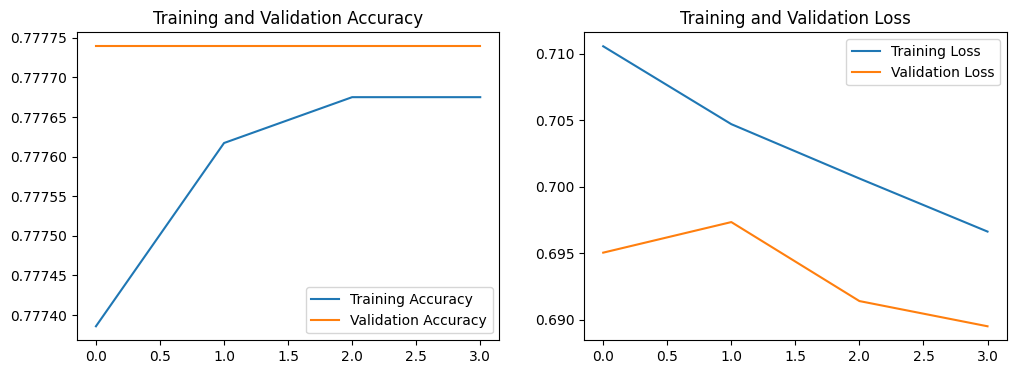

In [ ]:
# Plot training and validation accuracy over time
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()
